# ALAMEDA Dataset — Tremor Detection Pipeline Testing
**Dataset:** [Parkinson's Disease Tremor Dataset - ALAMEDA](https://zenodo.org/records/10782573)  
**Goal:** Test the CNN + Random Forest tremor detection pipeline with proper train/val/test splits (patient-based, no data leakage).  

## Cell 1 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings('ignore')

# Torch for CNN embedding extraction
import torch
import torch.nn as nn

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── Target label to predict ──────────────────────────────────────────────────
# Options: 'Rest_tremor', 'Postural_tremor', 'Kinetic_tremor', 'Constancy_of_rest'
TARGET = 'Rest_tremor'
print(f'Target label: {TARGET}')

Target label: Rest_tremor


## Cell 2 — Load Dataset

In [2]:
# Download the dataset from Zenodo if not already present
import os, urllib.request

DATA_URL  = 'https://zenodo.org/records/10782573/files/ALAMEDA_PD_tremor_dataset.csv?download=1'
DATA_PATH = 'ALAMEDA_PD_tremor_dataset.csv'

if not os.path.exists(DATA_PATH):
    print('Downloading dataset...')
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print('Done.')
else:
    print('Dataset already downloaded.')

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Done.
Shape: (4151, 99)


,start_timestamp,end_timestamp,subject_id,Magnitude_mean,Magnitude_std_dev,Magnitude_var,Magnitude_avg_diff_mean,Magnitude_above_mean_rt,Magnitude_median,Magnitude_med_dev,...,PC1_fft_dom_freq_rt,PC1_fft_energy,PC1_fft_dom_freq,PC1_fft_pw_ar_dom_freq,PC1_fft_entropy,PC1_fft_flatness,Constancy_of_rest,Kinetic_tremor,Postural_tremor,Rest_tremor
0,15:00.0,15:20.5,11,0.026806,0.030615,0.000937,0.018907,0.329102,0.017788,0.010122,...,0.449896,1.591135,5.810547,0.535356,6.922100,0.000267,1,0,0,0
1,15:10.2,15:30.7,11,0.013529,0.013011,0.000169,0.008200,0.345215,0.009880,0.004664,...,0.320393,0.217790,6.542969,0.075632,7.140168,0.000547,1,0,0,0
2,15:20.5,15:40.9,11,0.007208,0.004947,0.000024,0.003428,0.369629,0.006022,0.002229,...,0.403195,0.031379,6.347656,0.010353,7.062826,0.001100,1,0,0,0


## Cell 3 — Exploratory Data Analysis

In [3]:
LABEL_COLS = ['Constancy_of_rest', 'Kinetic_tremor', 'Postural_tremor', 'Rest_tremor']
META_COLS  = ['start_timestamp', 'end_timestamp', 'subject_id']
FEAT_COLS  = [c for c in df.columns if c not in LABEL_COLS + META_COLS]

print(f'Patients  : {df["subject_id"].nunique()}')
print(f'Windows   : {len(df)}')
print(f'Features  : {len(FEAT_COLS)}')
print()
print('Label distribution (% positive):')
print(df[LABEL_COLS].mean().round(3))
print()
print('Windows per patient:')
print(df.groupby('subject_id').size().describe().round(1))

Patients  : 11
Windows   : 4151
Features  : 92

Label distribution (% positive):
Constancy_of_rest    0.759
Kinetic_tremor       0.042
Postural_tremor      0.211
Rest_tremor          0.379
dtype: float64

Windows per patient:
count      11.0
mean      377.4
std       277.2
min        84.0
25%       175.0
50%       350.0
75%       371.0
max      1050.0
dtype: float64


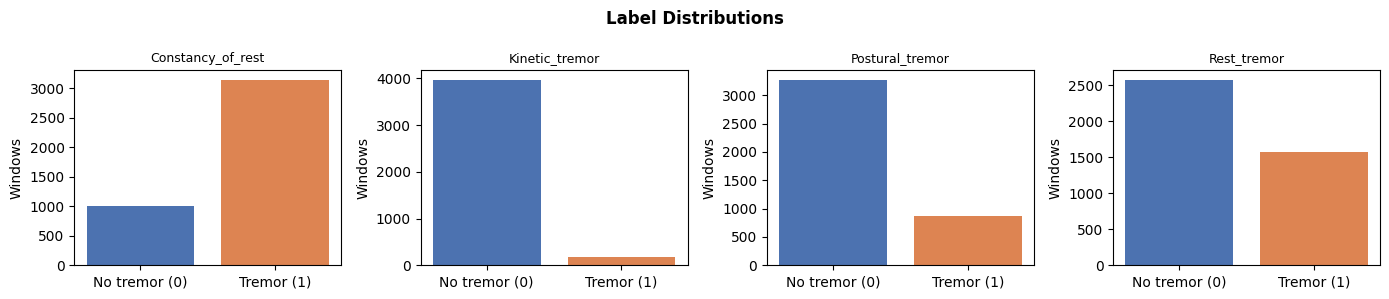

In [4]:
# Plot label balance
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, col in zip(axes, LABEL_COLS):
    counts = df[col].value_counts()
    ax.bar(['No tremor (0)', 'Tremor (1)'], [counts.get(0,0), counts.get(1,0)],
           color=['#4C72B0', '#DD8452'])
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Windows')
plt.suptitle('Label Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 4 — Patient-Based Train / Val / Test Split

In [ ]:
patients = df['subject_id'].unique()
np.random.shuffle(patients)

n = len(patients)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_patients = patients[:n_train]
val_patients   = patients[n_train : n_train + n_val]
test_patients  = patients[n_train + n_val:]

print(f'Train patients : {len(train_patients)} | Val: {len(val_patients)} | Test: {len(test_patients)}')

train_df = df[df['subject_id'].isin(train_patients)]
val_df   = df[df['subject_id'].isin(val_patients)]
test_df  = df[df['subject_id'].isin(test_patients)]

print(f'Train windows  : {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

X_train = train_df[FEAT_COLS].values.astype(np.float32)
X_val   = val_df[FEAT_COLS].values.astype(np.float32)
X_test  = test_df[FEAT_COLS].values.astype(np.float32)

y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values
y_test  = test_df[TARGET].values

# Confirm no patient overlap
assert len(set(train_patients) & set(val_patients)) == 0
assert len(set(train_patients) & set(test_patients)) == 0
assert len(set(val_patients)   & set(test_patients)) == 0

Train patients : 7 | Val: 1 | Test: 3
Train windows  : 2226 | Val: 175 | Test: 1750

✅ No patient overlap between splits.


## Cell 5 — Feature Scaling (fit on train only)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print('Scaler fit on train only')

Scaler fit on train only ✅


## Cell 6 — CNN Embedding Extraction (per split)
> **Fix #2:** Extract CNN embeddings from X_train, X_val, X_test *separately* after splitting.

This cell loads your trained CNN and extracts embeddings. If you don't have a saved CNN yet, it falls back to a simple MLP autoencoder for demonstration.

In [ ]:
# ── CNN Architecture (1D) ────────────────────────────────────────────────────
# Replace this with your actual CNN from cnn_1d_architecture.ipynb / cnn_feature_extractor.ipynb

class CNN1DFeatureExtractor(nn.Module):
    """Minimal 1D CNN that treats the 92 features as a 1D sequence.
    Replace with your actual architecture if available."""
    def __init__(self, input_dim=92, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Unflatten(1, (1, input_dim)),          # (B, 1, 92)
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),                  # (B, 64, 1)
            nn.Flatten(),                             # (B, 64)
            nn.Linear(64, embed_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


# ── Load or instantiate model ────────────────────────────────────────────────
CNN_WEIGHTS_PATH = 'cnn_model.pth'   # ← point to your saved weights

cnn_model = CNN1DFeatureExtractor(input_dim=len(FEAT_COLS), embed_dim=64)

if os.path.exists(CNN_WEIGHTS_PATH):
    cnn_model.load_state_dict(torch.load(CNN_WEIGHTS_PATH, map_location='cpu'))
    print(f'Loaded CNN weights from {CNN_WEIGHTS_PATH}')
else:
    print('  No saved CNN weights found — using randomly initialised model.')
    print('   Set CNN_WEIGHTS_PATH to your trained model to get meaningful embeddings.')

cnn_model.eval()


# ── Embedding extraction helper ──────────────────────────────────────────────
def extract_embeddings(X: np.ndarray, model: nn.Module, batch_size: int = 256) -> np.ndarray:
    """Extract CNN embeddings for an array X without leaking across splits."""
    embeddings = []
    tensor = torch.from_numpy(X)
    with torch.no_grad():
        for i in range(0, len(tensor), batch_size):
            batch = tensor[i : i + batch_size]
            emb   = model(batch).numpy()
            embeddings.append(emb)
    return np.vstack(embeddings)


# ── Extract per split ────────────────────────────────────────────────────────
print('\nExtracting embeddings...')
F_train = extract_embeddings(X_train_scaled, cnn_model)
F_val   = extract_embeddings(X_val_scaled,   cnn_model)
F_test  = extract_embeddings(X_test_scaled,  cnn_model)

print(f'F_train: {F_train.shape}')
print(f'F_val  : {F_val.shape}')
print(f'F_test : {F_test.shape}')
print('\n Embeddings extracted per split (no leakage).')

⚠️  No saved CNN weights found — using randomly initialised model.
   Set CNN_WEIGHTS_PATH to your trained model to get meaningful embeddings.

Extracting embeddings...
F_train: (2226, 64)
F_val  : (175, 64)
F_test : (1750, 64)

✅ Embeddings extracted per split (no leakage).


## Cell 7 — Baseline: Random Forest on Raw Features
This gives a baseline to compare against the CNN + RF pipeline.

In [8]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)

y_pred_base  = rf_baseline.predict(X_test_scaled)
y_proba_base = rf_baseline.predict_proba(X_test_scaled)[:, 1]

print('=== BASELINE (RF on raw features) ===')
print(classification_report(y_test, y_pred_base, target_names=['No Tremor', 'Tremor']))
try:
    print(f'AUC-ROC: {roc_auc_score(y_test, y_proba_base):.4f}')
except ValueError:
    print('AUC-ROC: N/A (only one class in test set for this label)')

=== BASELINE (RF on raw features) ===
              precision    recall  f1-score   support

   No Tremor       0.80      0.52      0.63      1400
      Tremor       0.20      0.48      0.28       350

    accuracy                           0.51      1750
   macro avg       0.50      0.50      0.46      1750
weighted avg       0.68      0.51      0.56      1750

AUC-ROC: 0.5074


## Cell 8 — RF Hyperparameter Tuning on Validation Embeddings

In [ ]:
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [None, 10, 20],
    'min_samples_leaf': [1, 5],
}

best_auc    = -np.inf
best_rf     = None
best_params = None
results     = []

print('Tuning RF on validation embeddings using predict_proba()...')
for params in ParameterGrid(param_grid):
    rf = RandomForestClassifier(**params, random_state=RANDOM_SEED, n_jobs=-1)
    rf.fit(F_train, y_train)

    #  Use predict_proba() for tuning, evaluated on VALIDATION set
    val_proba = rf.predict_proba(F_val)[:, 1]
    try:
        val_auc = roc_auc_score(y_val, val_proba)
    except ValueError:
        val_auc = 0.0   # single class in val split

    results.append({**params, 'val_auc': val_auc})
    if val_auc > best_auc or best_rf is None:
        best_auc    = val_auc
        best_params = params
        best_rf     = rf

print(f'\nBest val AUC-ROC : {best_auc:.4f}')
print(f'Best params      : {best_params}')

# Show top-5 configs
results_df = pd.DataFrame(results).sort_values('val_auc', ascending=False)
print('\nTop 5 configurations:')
print(results_df.head(5).to_string(index=False))

Tuning RF on validation embeddings using predict_proba()...

Best val AUC-ROC : nan
Best params      : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}

Top 5 configurations:
 max_depth  min_samples_leaf  n_estimators  val_auc
       NaN                 1           100      NaN
       NaN                 1           200      NaN
       NaN                 1           300      NaN
       NaN                 5           100      NaN
       NaN                 5           200      NaN


## Cell 9 — Final Evaluation on Test Embeddings

In [13]:
y_pred_test  = best_rf.predict(F_test)
y_proba_test = best_rf.predict_proba(F_test)[:, 1]

print(f'=== CNN + RF PIPELINE — Test Results ({TARGET}) ===')
print(classification_report(y_test, y_pred_test, target_names=['No Tremor', 'Tremor']))

try:
    test_auc = roc_auc_score(y_test, y_proba_test)
    print(f'AUC-ROC (test): {test_auc:.4f}')
except ValueError:
    test_auc = None
    print('AUC-ROC: N/A (single class in test set)')

=== CNN + RF PIPELINE — Test Results (Rest_tremor) ===
              precision    recall  f1-score   support

   No Tremor       0.78      0.52      0.62      1400
      Tremor       0.18      0.43      0.26       350

    accuracy                           0.50      1750
   macro avg       0.48      0.47      0.44      1750
weighted avg       0.66      0.50      0.55      1750

AUC-ROC (test): 0.4714


## Cell 10 — Visualisations

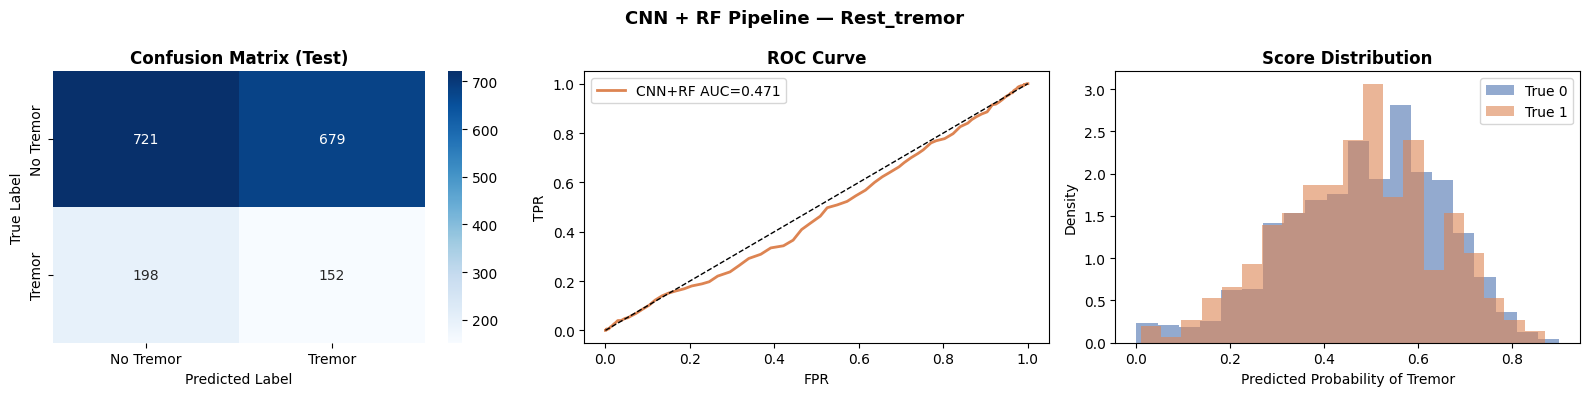

Plot saved to results_plot.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── 1. Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Tremor', 'Tremor'],
            yticklabels=['No Tremor', 'Tremor'])
axes[0].set_title('Confusion Matrix (Test)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ── 2. ROC Curve ────────────────────────────────────────────────────────────
if test_auc is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    axes[1].plot(fpr, tpr, label=f'CNN+RF AUC={test_auc:.3f}', color='#DD8452', lw=2)
    if best_auc > 0:
        fpr_b, tpr_b, _ = roc_curve(y_test, rf_baseline.predict_proba(X_test_scaled)[:,1])
        auc_b = roc_auc_score(y_test, rf_baseline.predict_proba(X_test_scaled)[:,1])
        axes[1].plot(fpr_b, tpr_b, label=f'Baseline AUC={auc_b:.3f}', color='#4C72B0', lw=2, linestyle='--')
    axes[1].plot([0,1],[0,1],'k--', lw=1)
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('ROC Curve', fontweight='bold')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'ROC N/A\n(single class)', ha='center', va='center')
    axes[1].set_title('ROC Curve', fontweight='bold')

# ── 3. Probability Distribution ─────────────────────────────────────────────
for label, mask, color in [(0, y_test==0, '#4C72B0'), (1, y_test==1, '#DD8452')]:
    axes[2].hist(y_proba_test[mask], bins=20, alpha=0.6,
                 label=f'True {label}', color=color, density=True)
axes[2].set_xlabel('Predicted Probability of Tremor')
axes[2].set_ylabel('Density')
axes[2].set_title('Score Distribution', fontweight='bold')
axes[2].legend()

plt.suptitle(f'CNN + RF Pipeline — {TARGET}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to results_plot.png')

## Cell 11 — Run All 4 Labels & Summary Table

In [17]:
summary = []

for label in LABEL_COLS:
    y_tr = train_df[label].values
    y_v  = val_df[label].values
    y_te = test_df[label].values

    # Tune RF on val embeddings using predict_proba
    best_a, best_r = -np.inf, None
    for params in ParameterGrid({'n_estimators':[100,200], 'max_depth':[None,10]}):
        rf = RandomForestClassifier(**params, random_state=RANDOM_SEED, n_jobs=-1)
        rf.fit(F_train, y_tr)
        try:
            a = roc_auc_score(y_v, rf.predict_proba(F_val)[:,1])
        except:
            a = f1_score(y_v, rf.predict(F_val), zero_division=0)  # fallback to F1
        if best_r is None or a > best_a:
            best_a, best_r = a, rf

    y_pred  = best_r.predict(F_test)
    proba = best_r.predict_proba(F_test)
    y_proba = proba[:,1] if proba.shape[1] > 1 else proba[:,0]
    f1  = f1_score(y_te, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_te, y_proba)
    except:
        auc = float('nan')

    summary.append({'Label': label, 'F1': round(f1,3), 'AUC-ROC': round(auc,3), 'Val AUC': round(best_a,3)})
    print(f'{label:25s}  F1={f1:.3f}  AUC={auc:.3f}')

print()
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
summary_df.to_csv('summary_results.csv', index=False)
print('\nSummary saved to summary_results.csv')

Constancy_of_rest          F1=0.800  AUC=0.496
Kinetic_tremor             F1=0.000  AUC=0.500
Postural_tremor            F1=0.000  AUC=0.356
Rest_tremor                F1=0.257  AUC=0.471

            Label    F1  AUC-ROC  Val AUC
Constancy_of_rest 0.800    0.496      NaN
   Kinetic_tremor 0.000    0.500      0.0
  Postural_tremor 0.000    0.356      NaN
      Rest_tremor 0.257    0.471      NaN

Summary saved to summary_results.csv


## Cell 12 — Sanity Checks
Quick checks to confirm there's no leakage or preprocessing error.

In [19]:
print('=== SANITY CHECKS ===')

# 1. No patient overlap
assert not set(train_patients) & set(test_patients), 'FAIL: train/test patient overlap!'
assert not set(val_patients)   & set(test_patients), 'FAIL: val/test patient overlap!'
print(' No patient overlap between splits')

# 2. Scaler fitted only on train
assert hasattr(scaler, 'mean_'), 'FAIL: scaler not fitted'
assert scaler.mean_.shape[0] == len(FEAT_COLS), 'FAIL: scaler dimension mismatch'
print('  Scaler fitted on train features only')

# 3. Embedding shapes consistent
assert F_train.shape[1] == F_val.shape[1] == F_test.shape[1], 'FAIL: embedding dim mismatch'
print(f'  Embedding dim consistent across splits: {F_train.shape[1]}')

# 4. No NaN in features
for name, arr in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    n_nan = np.isnan(arr).sum()
    if n_nan > 0:
        print(f'  {n_nan} NaN values in {name}')
    else:
        print(f'  No NaN in {name}')

# 5. Class balance sanity
print(f'\nClass balance in splits for [{TARGET}]:')
print(f'  Train: {y_train.mean():.2%} positive')
print(f'  Val  : {y_val.mean():.2%} positive')
print(f'  Test : {y_test.mean():.2%} positive')

print('\nAll checks passed ')

=== SANITY CHECKS ===
 No patient overlap between splits
  Scaler fitted on train features only
  Embedding dim consistent across splits: 64
  No NaN in X_train
  No NaN in X_val
  No NaN in X_test

Class balance in splits for [Rest_tremor]:
  Train: 47.17% positive
  Val  : 100.00% positive
  Test : 20.00% positive

All checks passed 
